In [1]:
import sys

# _NOTEBOOK_DIR : contains rephrase_plot_utils.py
# _GIDON_SCRIPTS: contains tfsplt_future_past_utils.py (select_lag_range_and_last_columns)
#                 and tfsplt_future_past_helpers.py
_NOTEBOOK_DIR  = '/scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/scripts/gidon'
_GIDON_SCRIPTS = '/scratch/gpfs/HASSON/gidon/247-plotting/scripts'
for _p in [_GIDON_SCRIPTS, _NOTEBOOK_DIR]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Compat patch: matplotlib >= 3.9 rejects ax.set_title(..., color=None).
# Gidon's plot_effect_glassbrain passes color=None when no style color applies.
# Drop the kwarg silently so the default color is used instead.
_orig_axes_set_title = matplotlib.axes.Axes.set_title
def _compat_set_title(self, label, *args, **kwargs):
    if 'color' in kwargs and kwargs['color'] is None:
        del kwargs['color']
    return _orig_axes_set_title(self, label, *args, **kwargs)
matplotlib.axes.Axes.set_title = _compat_set_title

import argparse
import pandas as pd
import numpy as np
import importlib

import tfsplt_future_past_utils as pu
import rephrase_plot_utils as ru
from tfsplt_future_past_helpers import render_brainplot_panels

## Parameters

In [2]:
class Args(argparse.Namespace):
    rois = [
        "IFG", "MTG", "STG", "preCG", "postCG",
        "rostralmiddlefrontal", "superiorfrontal", "supramarginal",
        "ITG", "TP", "fusiform", "All",
    ]
    lines   = ["joint", "word", "sentence", "sentence2"]
    # original=gold, synonym=blue, paronym=orange, random=grey
    # colors  = ["gold", "#2196F3", "#FF5722", "#9E9E9E"]
    colors  = ["black", "#2196F3", "#FF5722", "#9E9E9E"]
    legends = ["joint", "word", "future", "past"]
    lags = {
        "lags_all":       np.arange(-2000, 2001, 50),
        "lags_plt":       np.arange(-2000, 2001, 50),
        "lag_ticks":      np.arange(-2000, 2001, 500),
        "lag_tick_labels": np.arange(-2, 2.001, 0.5),
    }
    res_dir = '/scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/results/figures'

args = Args()

## Load data

Conditions compared:
| Key | Description |
|---|---|
| `original` | Original sentences, scored on rephrased-filtered word set |
| `synonym` | Synonym replacements, rephrased-filtered |
| `paronym` | Paronym replacements (gpt2-medium) |
| `random` | Randomly shuffled word embeddings (null baseline) |

In [3]:
importlib.reload(pu)
importlib.reload(ru)

res_d  = "/scratch/gpfs/HASSON/gidon/247-encoding-dev/results/tfs"
LAG_MIN, LAG_MAX = -2000, 2000

def _load(path_template, mode):
    df = pu.load_res_add_roi_threshold(path_template, thresh=None)
    df = pu.select_lag_range_and_last_columns(df, LAG_MIN, LAG_MAX)
    df['label3'] = df['label3'].str.replace('_banded_', '', regex=False)
    print(f"  {'comp' if mode == 'comp' else 'prod'}: {len(df)} rows")
    return df

# ---------- Original (rephrased-filtered) ----------
print("Original:")
_orig_tmpl = (
    f"{res_d}/gp-tfs-%s-mistral-bandedRidge-lag60-50-all-static_future_past-"
    "original_pca300_drop-short_mistral_original_word_trained_sentence_cnxt_0008"
    "_rephrased_filtered"
)
original_c = _load(_orig_tmpl + "_comp.csv", 'comp')
original_p = _load(_orig_tmpl + "_prod.csv", 'prod')

# ---------- Synonym (rephrased-filtered) ----------
print("Synonym:")
_syn_tmpl = (
    f"{res_d}/gp-tfs-%s-mistral-bandedRidge-lag60-50-all-static_future_past-"
    "original_pca300_drop-short_mistral_synonym_word_trained_sentence_cnxt_0008"
    "_rephrased_filtered"
)
synonym_c = _load(_syn_tmpl + "_comp.csv", 'comp')
synonym_p = _load(_syn_tmpl + "_prod.csv", 'prod')

# ---------- Paronym (gpt2-medium) ----------
print("Paronym:")
_par_tmpl = (
    f"{res_d}/gp-tfs-%s-gpt2-medium-bandedRidge-lag60-50-all-"
    "paronym_future_past-pca300_drop-short_cnxt_0008"
)
paronym_c = _load(_par_tmpl + "_comp.csv", 'comp')
paronym_p = _load(_par_tmpl + "_prod.csv", 'prod')

# ---------- Random word embeddings (null baseline) ----------
print("Random word embeddings:")
_rand_tmpl = (
    f"{res_d}/gp-tfs-%s-mistral-bandedRidge-lag60-50-all-static_future_past-"
    "original_pca300_drop-short_mistral_random_word_trained_sentence_cnxt_0008"
)
random_c = _load(_rand_tmpl + "_comp.csv", 'comp')
random_p = _load(_rand_tmpl + "_prod.csv", 'prod')

Original:
  comp: 2592 rows
  prod: 2504 rows
Synonym:
  comp: 2532 rows
  prod: 2516 rows
Paronym:
  comp: 2644 rows
  prod: 2644 rows
Random word embeddings:
  comp: 2576 rows
  prod: 2532 rows


## Electrode selection

Electrodes are selected based on **joint_max** (peak joint-model performance over
lags −2000 to +2000 ms) in the **original** condition ≥ 0.1.  
The same electrode set is then applied to all four conditions (inner intersection).

In [4]:
CONDITION_NAMES = ["original", "synonym", "paronym", "random"]
JOINT_MAX_THRESH = 0.1

condition_dfs_c = {
    "original": original_c,
    "synonym":  synonym_c,
    "paronym":  paronym_c,
    "random":   random_c,
}
condition_dfs_p = {
    "original": original_p,
    "synonym":  synonym_p,
    "paronym":  paronym_p,
    "random":   random_p,
}

# ---- Comprehension ----
# align_lag_columns so select_electrodes_by_joint_max can find numeric columns
lag_cols = np.arange(LAG_MIN, LAG_MAX + 50, 50)
ru.align_lag_columns(list(condition_dfs_c.values()), lag_cols)
ru.align_lag_columns(list(condition_dfs_p.values()), lag_cols)

selected_elecs_c = ru.select_electrodes_by_joint_max(
    original_c, threshold=JOINT_MAX_THRESH
)
selected_elecs_p = ru.select_electrodes_by_joint_max(
    original_p, threshold=JOINT_MAX_THRESH
)

filtered_c, common_c = ru.intersect_conditions(condition_dfs_c, selected_elecs_c)
filtered_p, common_p = ru.intersect_conditions(condition_dfs_p, selected_elecs_p)

print(f"Comprehension: {len(selected_elecs_c)} pass joint_max≥{JOINT_MAX_THRESH}, "
      f"{len(common_c)} shared across all 4 conditions")
print(f"Production:    {len(selected_elecs_p)} pass joint_max≥{JOINT_MAX_THRESH}, "
      f"{len(common_p)} shared across all 4 conditions")

roi_results_c = ru.build_roi_results(filtered_c, CONDITION_NAMES, args.rois)
roi_results_p = ru.build_roi_results(filtered_p, CONDITION_NAMES, args.rois)

Comprehension: 298 pass joint_max≥0.1, 279 shared across all 4 conditions
Production:    267 pass joint_max≥0.1, 246 shared across all 4 conditions


---
## Lineplots

One figure per ROI showing the **word** band for all four conditions overlaid.
Electrodes are the same in every condition (joint_max-selected, intersected).

### Comprehension

IFG: 45 electrodes


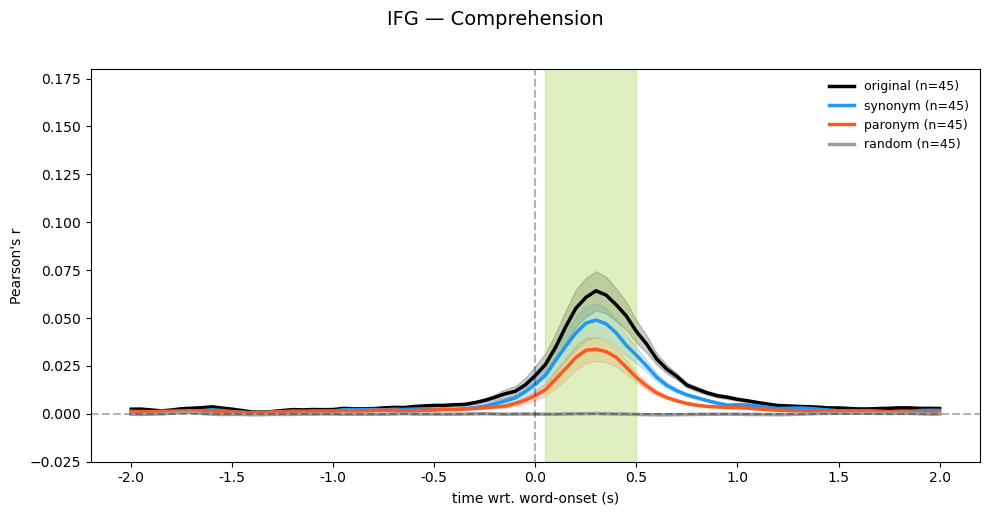

MTG: 18 electrodes


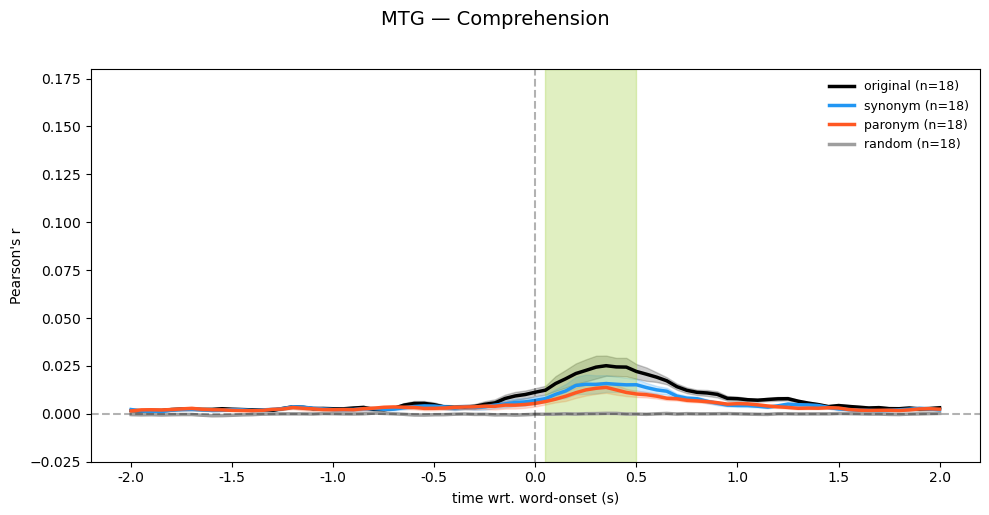

STG: 28 electrodes


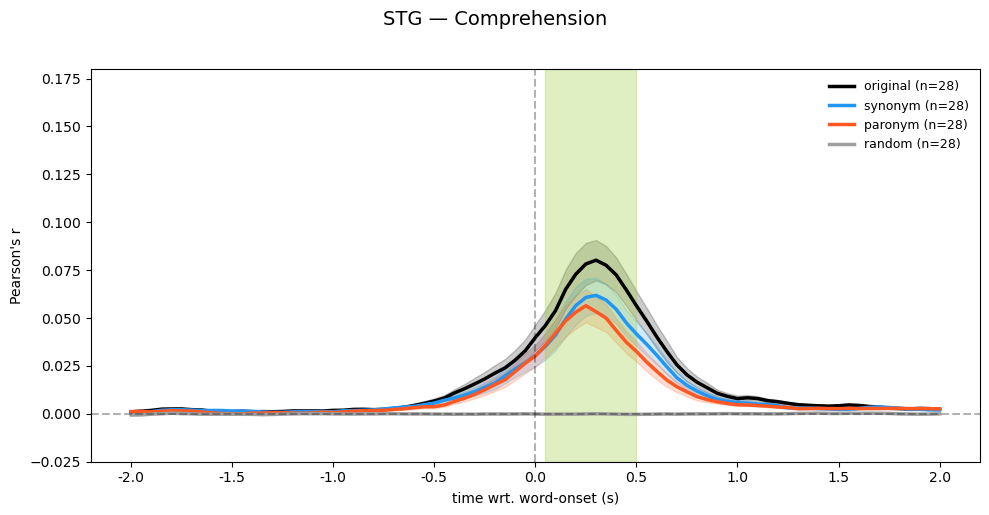

preCG: 24 electrodes


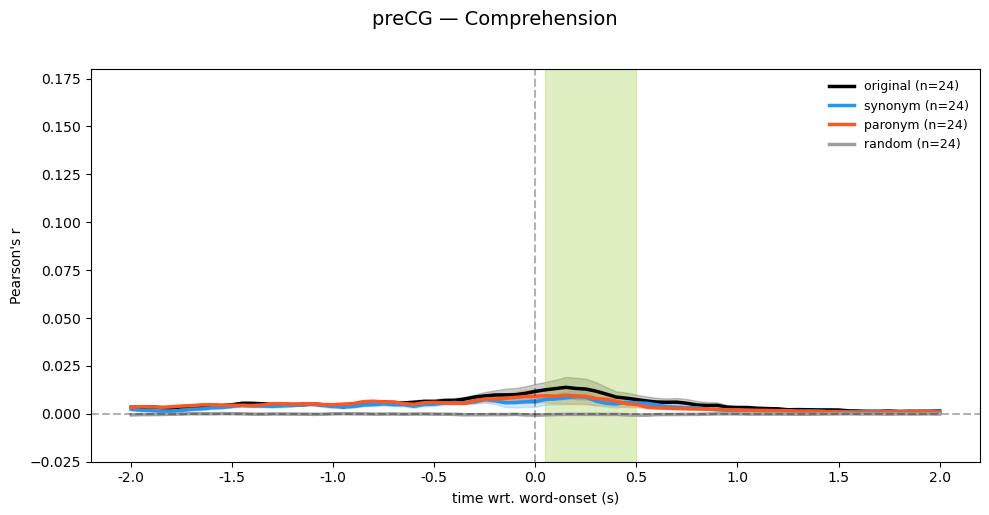

postCG: 13 electrodes


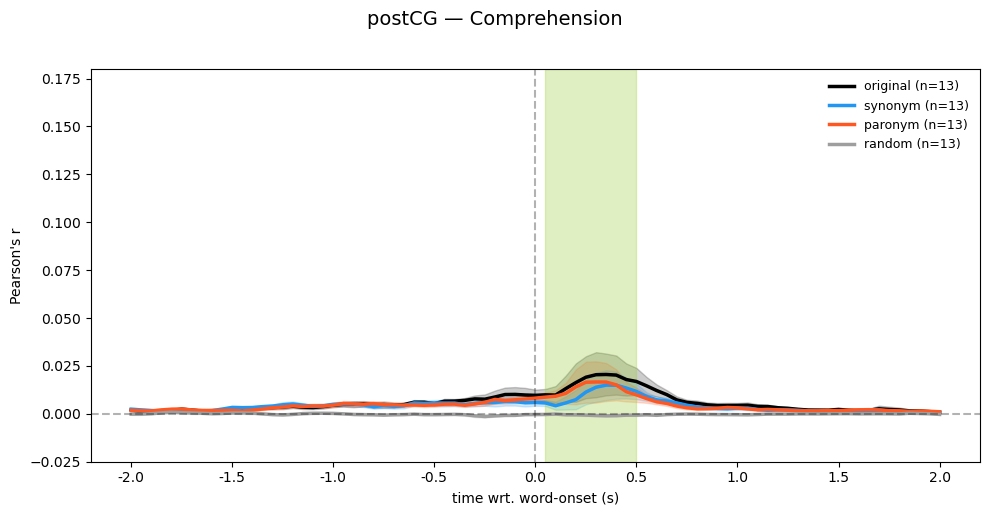

rostralmiddlefrontal: 22 electrodes


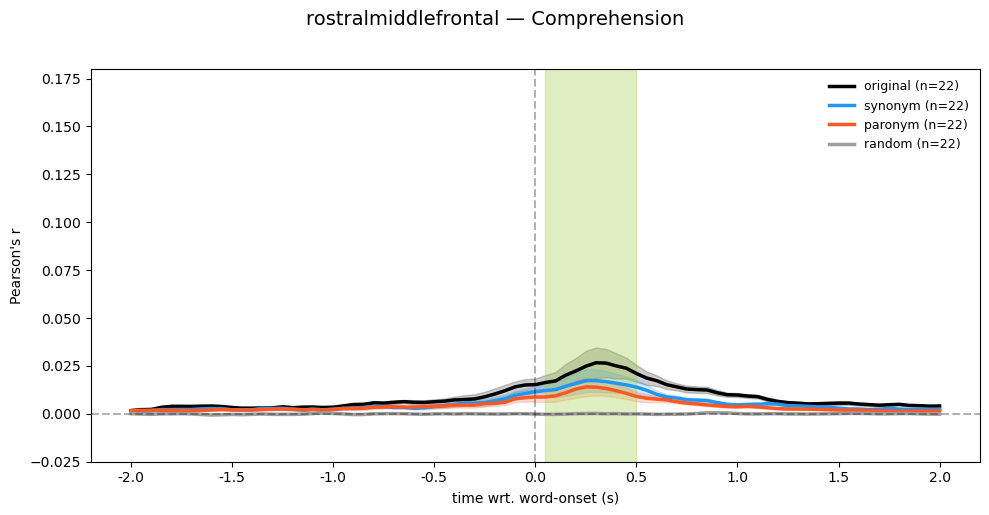

superiorfrontal: 8 electrodes


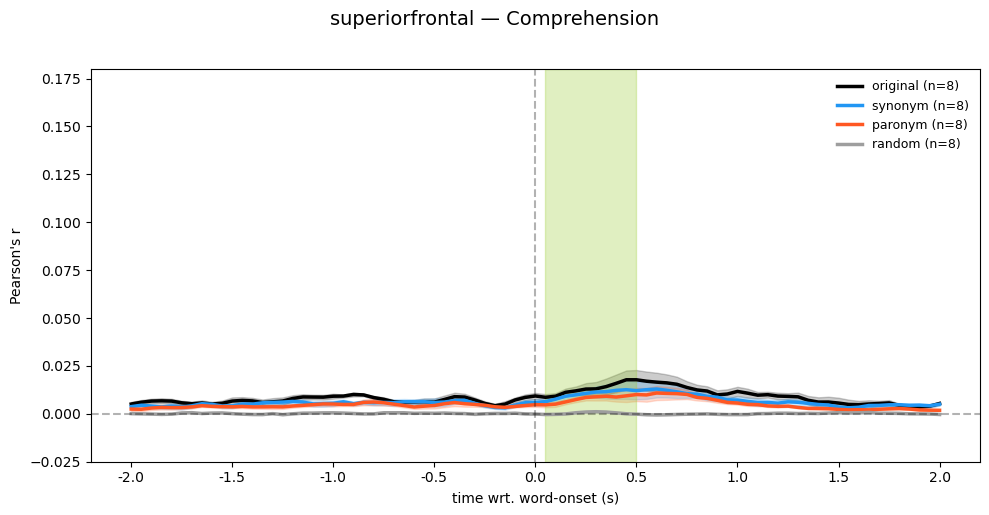

supramarginal: 14 electrodes


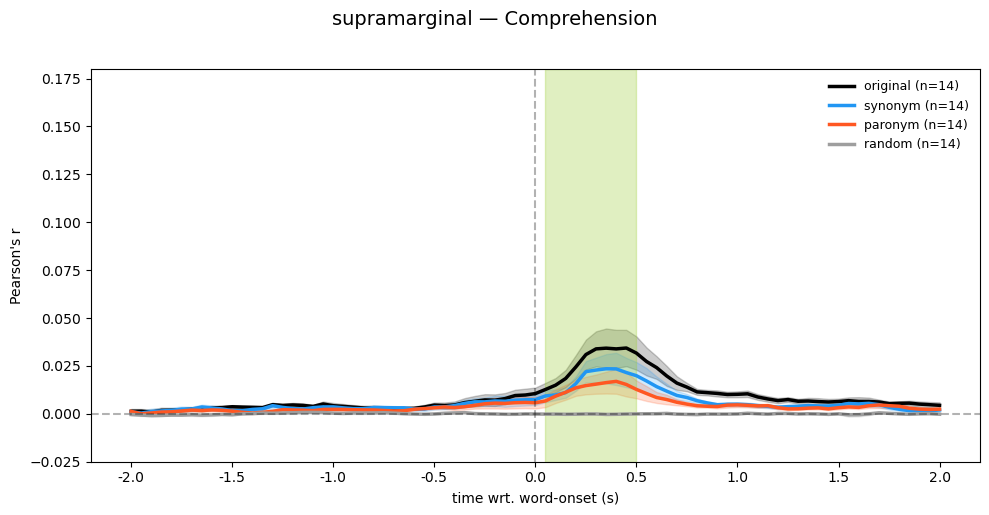

ITG: 9 electrodes


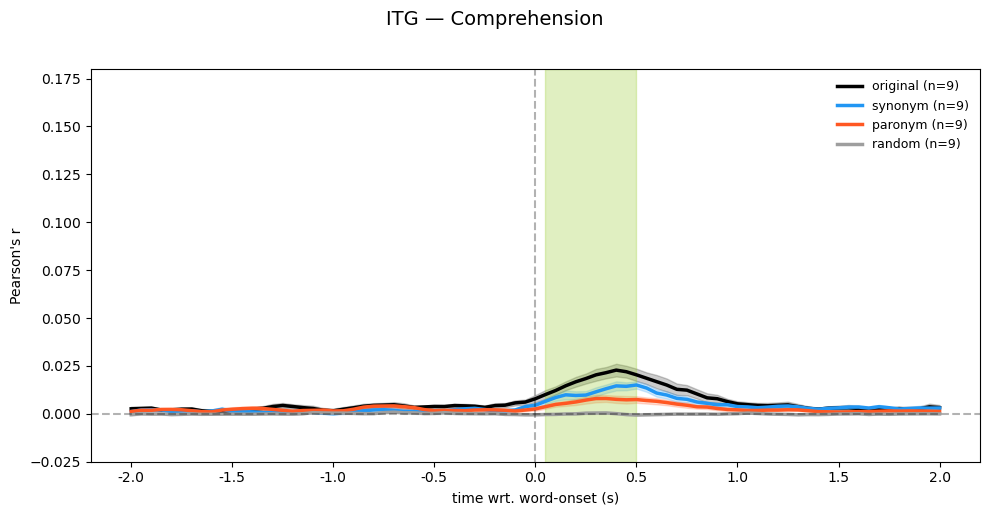

TP: 8 electrodes


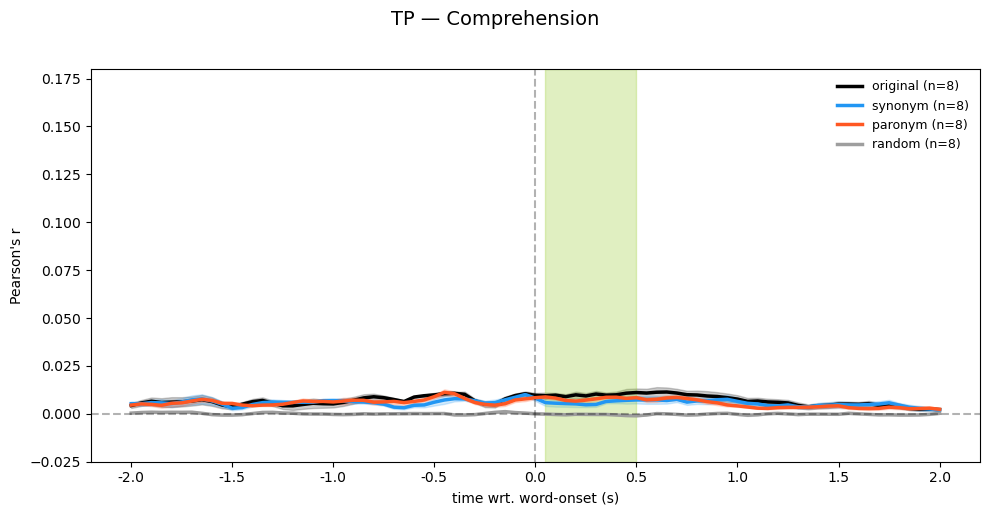

fusiform: 6 electrodes


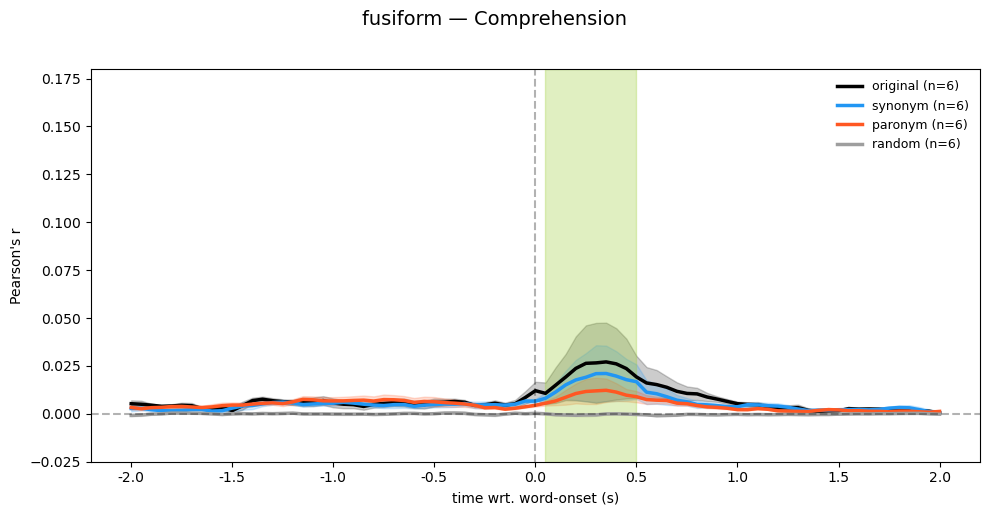

All: 283 electrodes


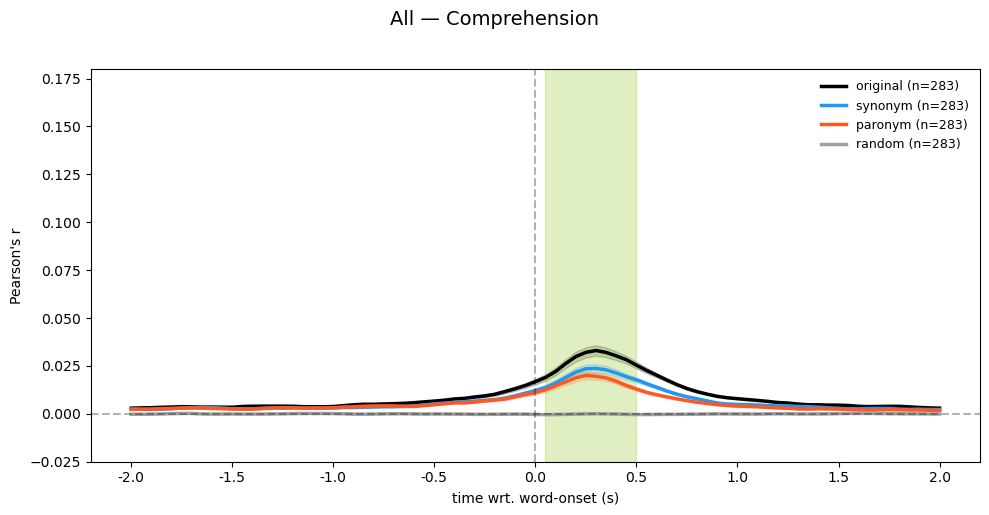

In [5]:
rois_to_plot_c = [
    roi for roi in args.rois
    if roi_results_c.get((0, 'joint', roi)) is not None
    and len(roi_results_c[(0, 'joint', roi)]) > 2
]

for roi in rois_to_plot_c:
    n_elecs = len(roi_results_c.get((0, 'joint', roi), []))
    print(f"{roi}: {n_elecs} electrodes")
    ru.plot_rephrase_lineplots(
        args, roi_results_c, roi, CONDITION_NAMES, mode='comp', plot_bands=True
    )

### Production

IFG: 43 electrodes


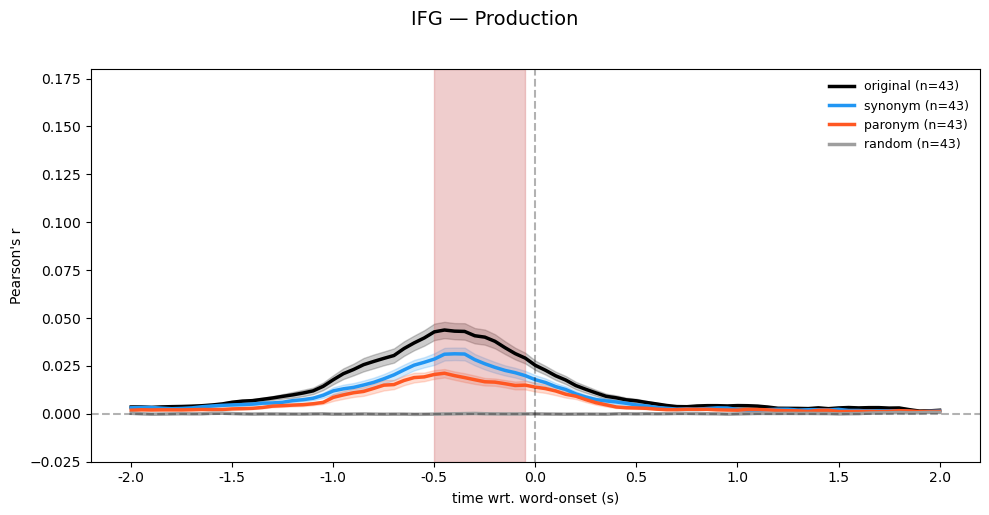

MTG: 19 electrodes


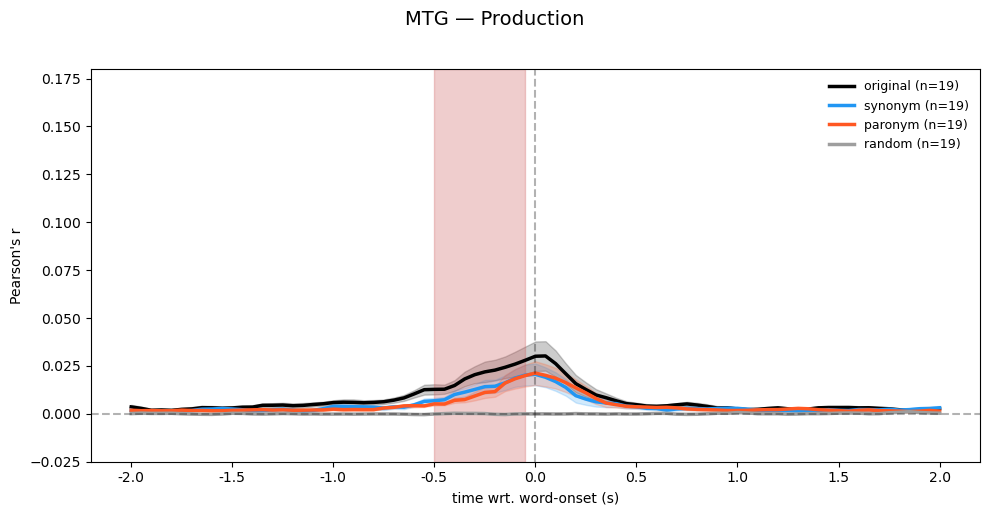

STG: 29 electrodes


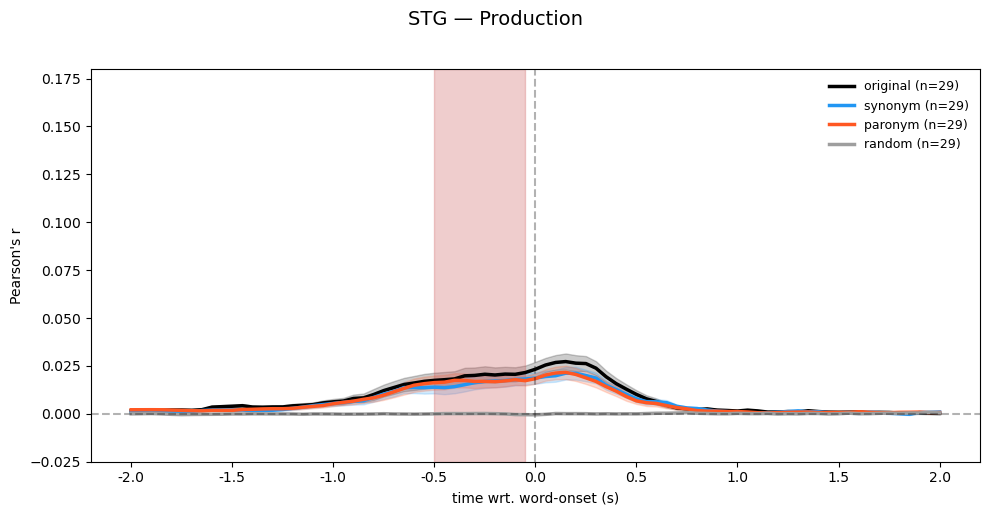

preCG: 22 electrodes


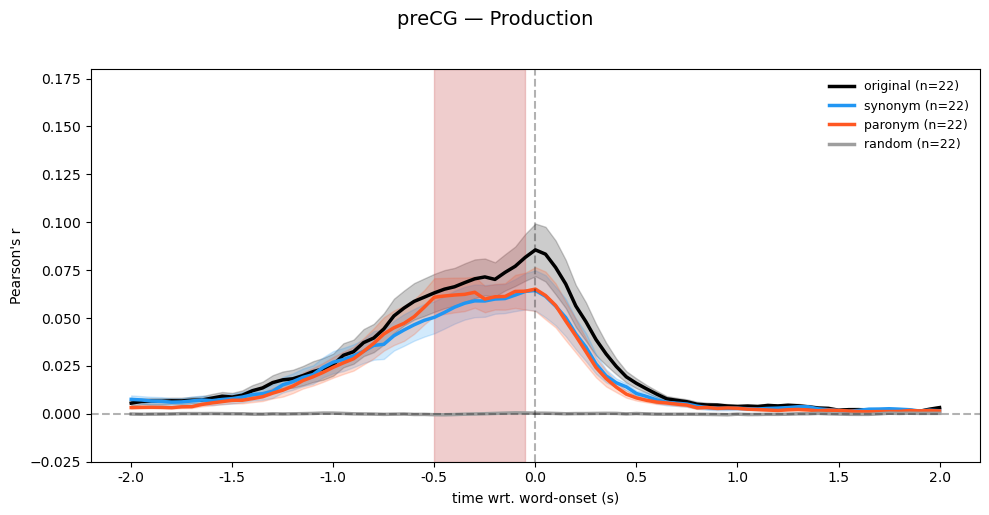

postCG: 18 electrodes


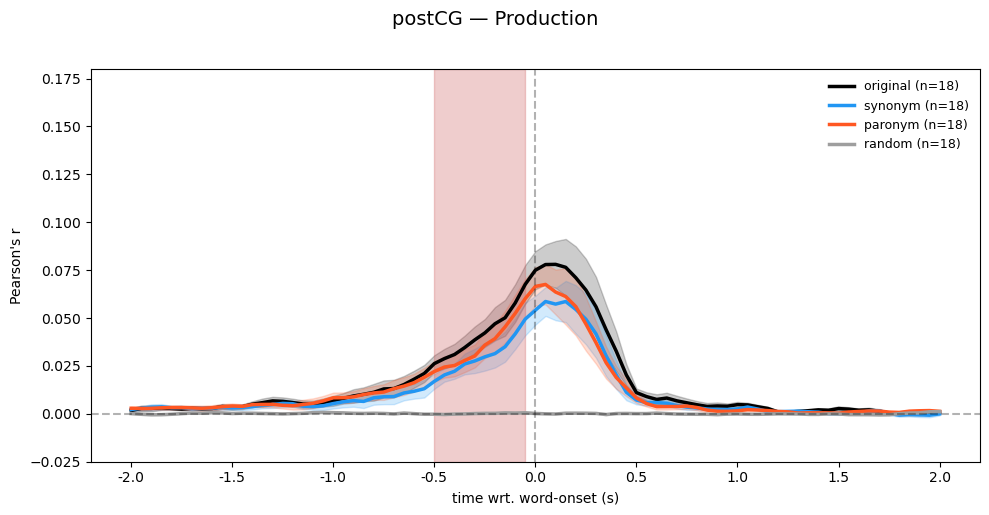

rostralmiddlefrontal: 19 electrodes


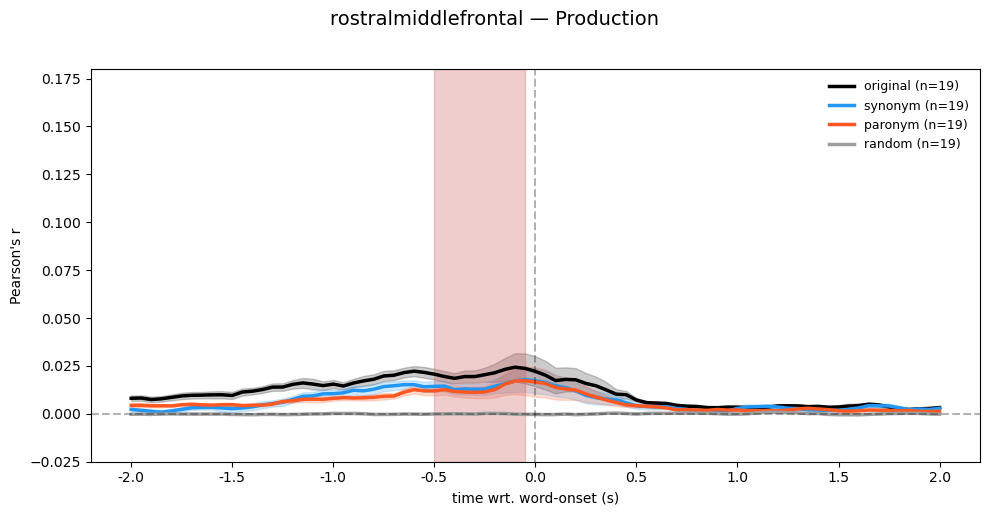

superiorfrontal: 5 electrodes


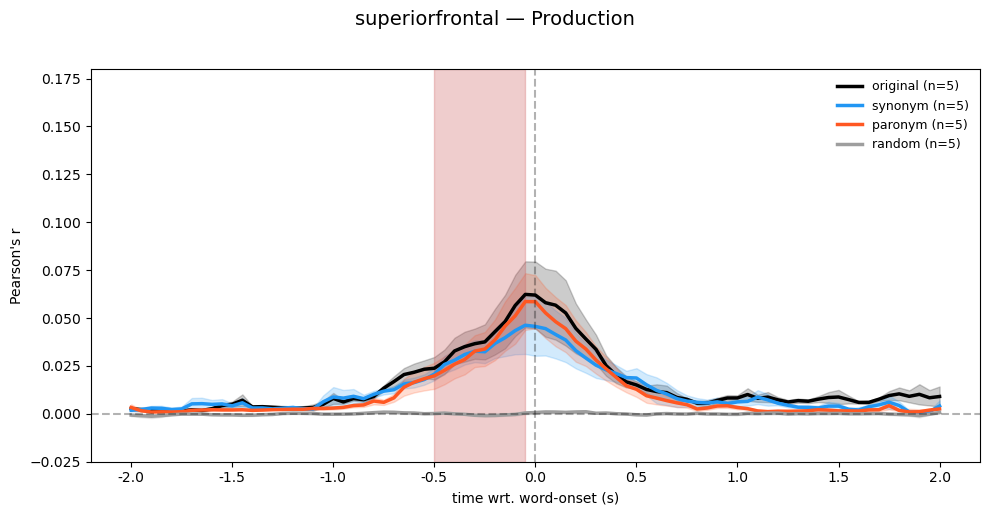

supramarginal: 10 electrodes


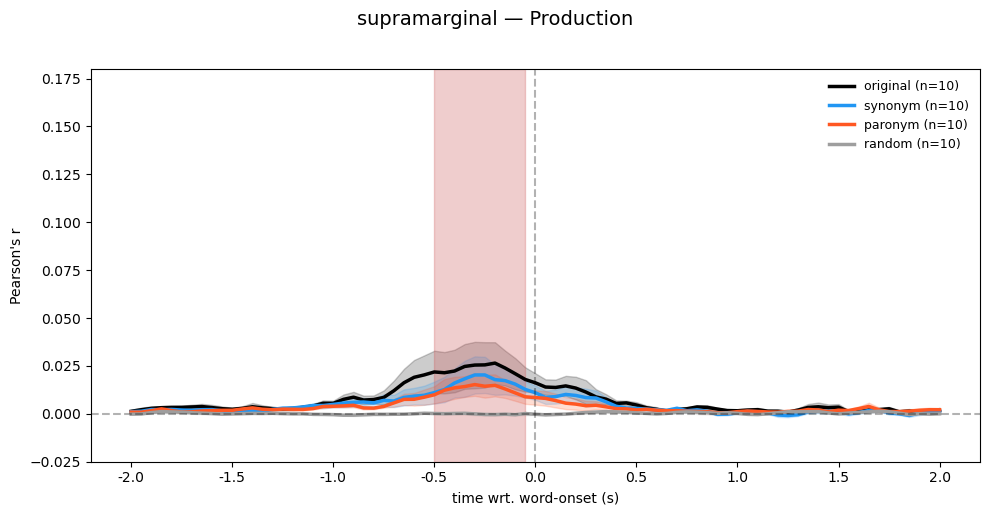

ITG: 9 electrodes


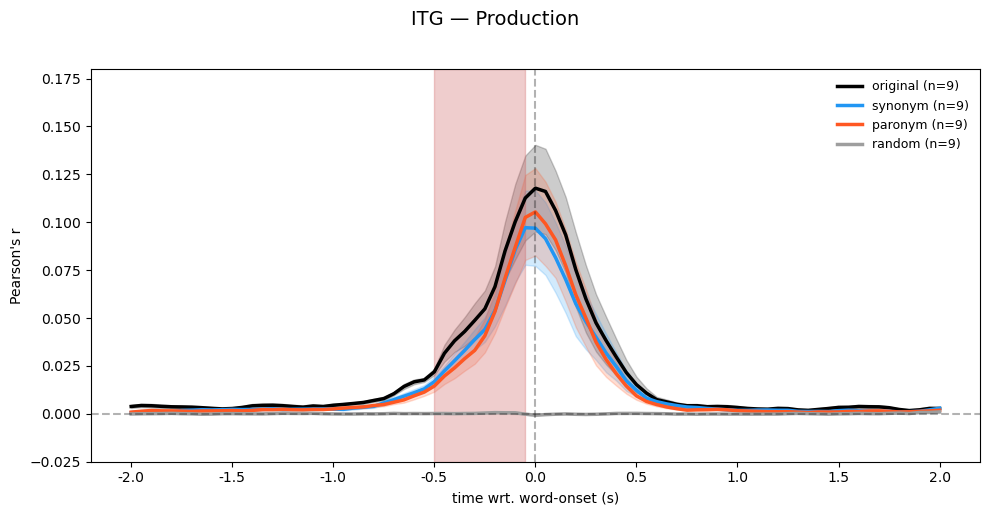

TP: 7 electrodes


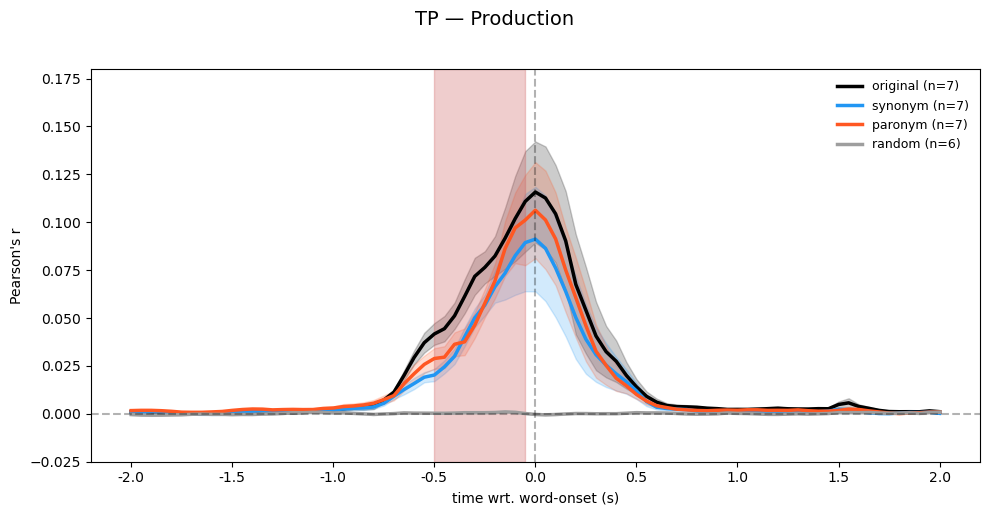

fusiform: 5 electrodes


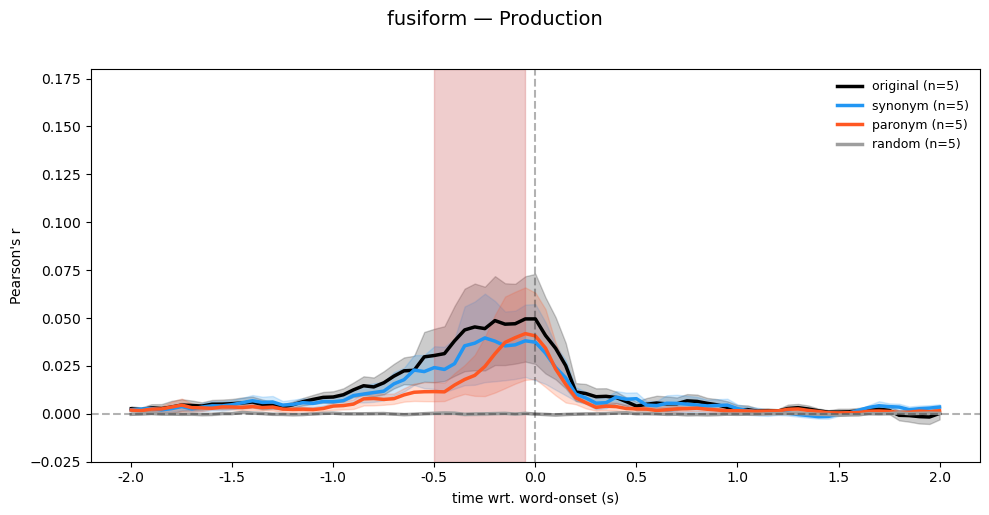

All: 260 electrodes


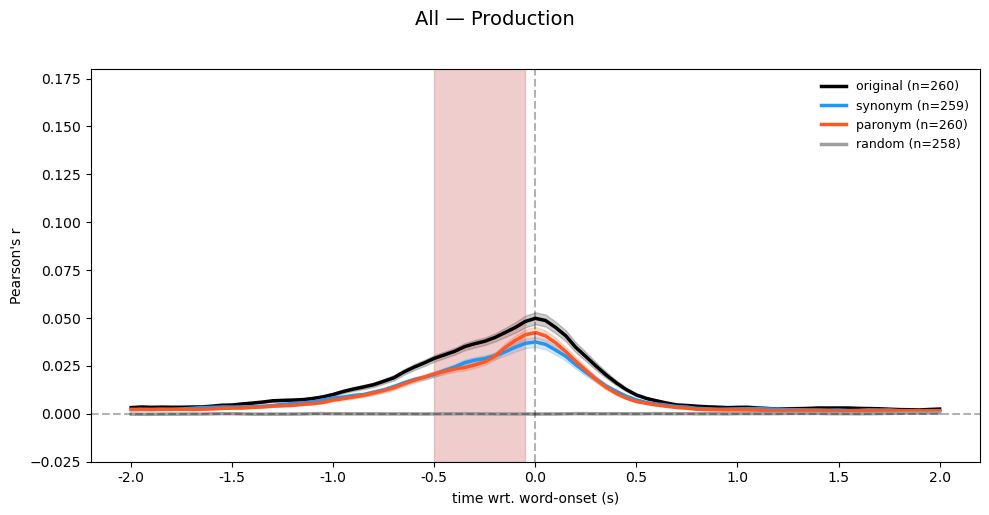

In [6]:
rois_to_plot_p = [
    roi for roi in args.rois
    if roi_results_p.get((0, 'joint', roi)) is not None
    and len(roi_results_p[(0, 'joint', roi)]) > 2
]

for roi in rois_to_plot_p:
    n_elecs = len(roi_results_p.get((0, 'joint', roi), []))
    print(f"{roi}: {n_elecs} electrodes")
    ru.plot_rephrase_lineplots(
        args, roi_results_p, roi, CONDITION_NAMES, mode='prod', plot_bands=True
    )

---
## Brainplots

**Color** encodes **synonym vs paronym** (per-electrode % change at peak difference)
using the same colors as the lineplots above:
- Blue (`#2196F3`) → synonym > paronym
- Orange (`#FF5722`) → paronym > synonym

**Size** encodes **original vs random** (max absolute difference):
- Larger dot → bigger difference from shuffled baseline

**Electrode inclusion** (all must pass):
- `original` joint max ≥ 0.1 over [−1000, +1000 ms]
- `original` word-band max ≥ 0.025 (word-peak floor)
- `|orig − syn|` ≥ 0.01 **or** `|orig − par|` ≥ 0.01 (rephrasing must change the
  encoding measurably for at least one variant — excludes electrodes where
  rephrasing had no effect at all, while keeping electrodes where synonym and
  paronym shift similarly relative to original)

In [ ]:
# Lag grid (columns are already aligned from electrode-selection cell)
lag_cols = np.arange(LAG_MIN, LAG_MAX + 50, 50)

time_window_full = [int(c) for c in lag_cols if -1000 <= c <= 1000]

time_windows = {
    ("comp", "word"): time_window_full,
    ("prod", "word"): time_window_full,
}

plot_order = [
    ("comp", "word", "Comprehension - Word"),
    ("prod", "word", "Production - Word"),
]

# ---------- Score settings ----------
COLOR_PAIR   = ("synonym", "paronym")   # Blue = synonym > paronym
SIZE_PAIR    = ("original", "random")   # Larger = more difference from random baseline
DENOM_PAIR   = ("original", "random")   # Denominator for percent-change normalization
SCORE_MODE   = "percent_change_at_max_diff"
SIZE_MODE    = "max_abs_diff"
TOP_N_LAGS   = 10
SIZE_MIN, SIZE_MAX = 10, 90

VALUE_THRESHOLDS       = {"original": 0.1}
THRESHOLD_TIME_WINDOWS = {"original": time_window_full}

# ---------- Additional electrode-quality thresholds ----------
# 1) Word-band floor: drop electrodes whose own word-band peak (on the
#    original condition) is too weak to be a real word effect.
WORD_PEAK_THRESH = 0.025
OWN_BAND_VALUE_THRESHOLDS = {"original": WORD_PEAK_THRESH}

# 2) Rephrase-effect floor: drop electrodes where rephrasing changed
#    *nothing* -- i.e. neither synonym nor paronym differs from original.
#    OR semantics: passing on just one of the two pairs is enough, since an
#    electrode where only synonym shifts (or only paronym shifts) still shows
#    a genuine effect of rephrasing, not "no effect."
DIFF_MIN = 0.01
MIN_DIFF_ANY = [
    ("original", "synonym", DIFF_MIN),
    ("original", "paronym", DIFF_MIN),
]

print("=== Brainplot settings ===")
print(f"  Band       : word  |  Window: {time_window_full[0]}..{time_window_full[-1]} ms")
print(f"  Color pair : {COLOR_PAIR[0]} vs {COLOR_PAIR[1]}")
print(f"  Size pair  : {SIZE_PAIR[0]} vs {SIZE_PAIR[1]}")
print(f"  Score mode : {SCORE_MODE}  |  Top N lags: {TOP_N_LAGS}")
print(f"  Joint threshold     : original max >= {VALUE_THRESHOLDS['original']} "
      f"over {time_window_full[0]}..{time_window_full[-1]} ms")
print(f"  Word-peak threshold : original word-band max >= {WORD_PEAK_THRESH}")
print(f"  Rephrase-effect floor: |orig-syn| >= {DIFF_MIN} OR |orig-par| >= {DIFF_MIN}")

In [ ]:
data_by_mode = {
    "comp": {
        "synonym":  synonym_c,
        "paronym":  paronym_c,
        "original": original_c,
        "random":   random_c,
    },
    "prod": {
        "synonym":  synonym_p,
        "paronym":  paronym_p,
        "original": original_p,
        "random":   random_p,
    },
}

# Orange → grey → blue, matching lineplot colors for paronym and synonym
_word_cmap = ru.paronym_grey_synonym_cmap("word_cmap")
cmaps = {"word": _word_cmap}
colorbar_labels = {"word": "Blue = synonym > paronym  |  Orange = paronym > synonym"}

panel_scores = []
for mode, label3, desc in plot_order:
    cfg = data_by_mode[mode]
    tw  = time_windows[(mode, label3)]
    print(f"Computing scores: {desc} ({tw[0]}..{tw[-1]} ms)")
    scores = ru.compute_brainplot_scores(
        condition_dfs=cfg,
        label3=label3,
        time_window=tw,
        color_pair=COLOR_PAIR,
        value_thresholds=VALUE_THRESHOLDS,
        score_mode=SCORE_MODE,
        size_pair=SIZE_PAIR,
        size_time_window=tw,
        size_mode=SIZE_MODE,
        size_min=SIZE_MIN,
        size_max=SIZE_MAX,
        threshold_time_window=THRESHOLD_TIME_WINDOWS,
        denominator_pair=DENOM_PAIR,
        threshold_label3="joint",
        top_n_lags=TOP_N_LAGS,
        own_band_value_thresholds=OWN_BAND_VALUE_THRESHOLDS,
        min_diff_any=MIN_DIFF_ANY,
    ).assign(mode=mode)
    print(f"  → {len(scores)} electrodes passed thresholds")
    panel_scores.append(scores)

electrode_scores = (
    pd.concat(panel_scores, ignore_index=True)
    if panel_scores else pd.DataFrame()
)
print(f"\nTotal electrode × panel rows: {len(electrode_scores)}")

In [ ]:
importlib.reload(ru)

# Keep only electrodes with known MNI coordinates.
# plot_effect_glassbrain does a left merge with the coordinate file, so
# unmatched electrodes get NaN MNI_X/Y/Z, which crashes nilearn's plot_markers.
electrode_scores_coords = ru.filter_to_known_coords(electrode_scores)
print(f"{len(electrode_scores)} total rows → {len(electrode_scores_coords)} with known coords")

ru.render_rephrase_brainplot_panels(
    electrode_scores=electrode_scores_coords,
    plot_order=plot_order,
    cmaps=cmaps,
    colorbar_labels=colorbar_labels,
    score_mode=SCORE_MODE,
    size_pair_labels=SIZE_PAIR,
    use_size_encoding=True,
)

### Raw diff brainplots (unscaled)

Same electrode set but color = **mean synonym − mean paronym** in Pearson r units
at the top-N lags where their difference is largest.  
Colorbar is auto-scaled symmetrically to the data (no ±75 normalization).  
Size still encodes original vs random.

raw_diff brainplots | vmin=-0.0646  vmax=0.0646
  Comprehension - Word: 245 electrodes
  Production - Word: 237 electrodes


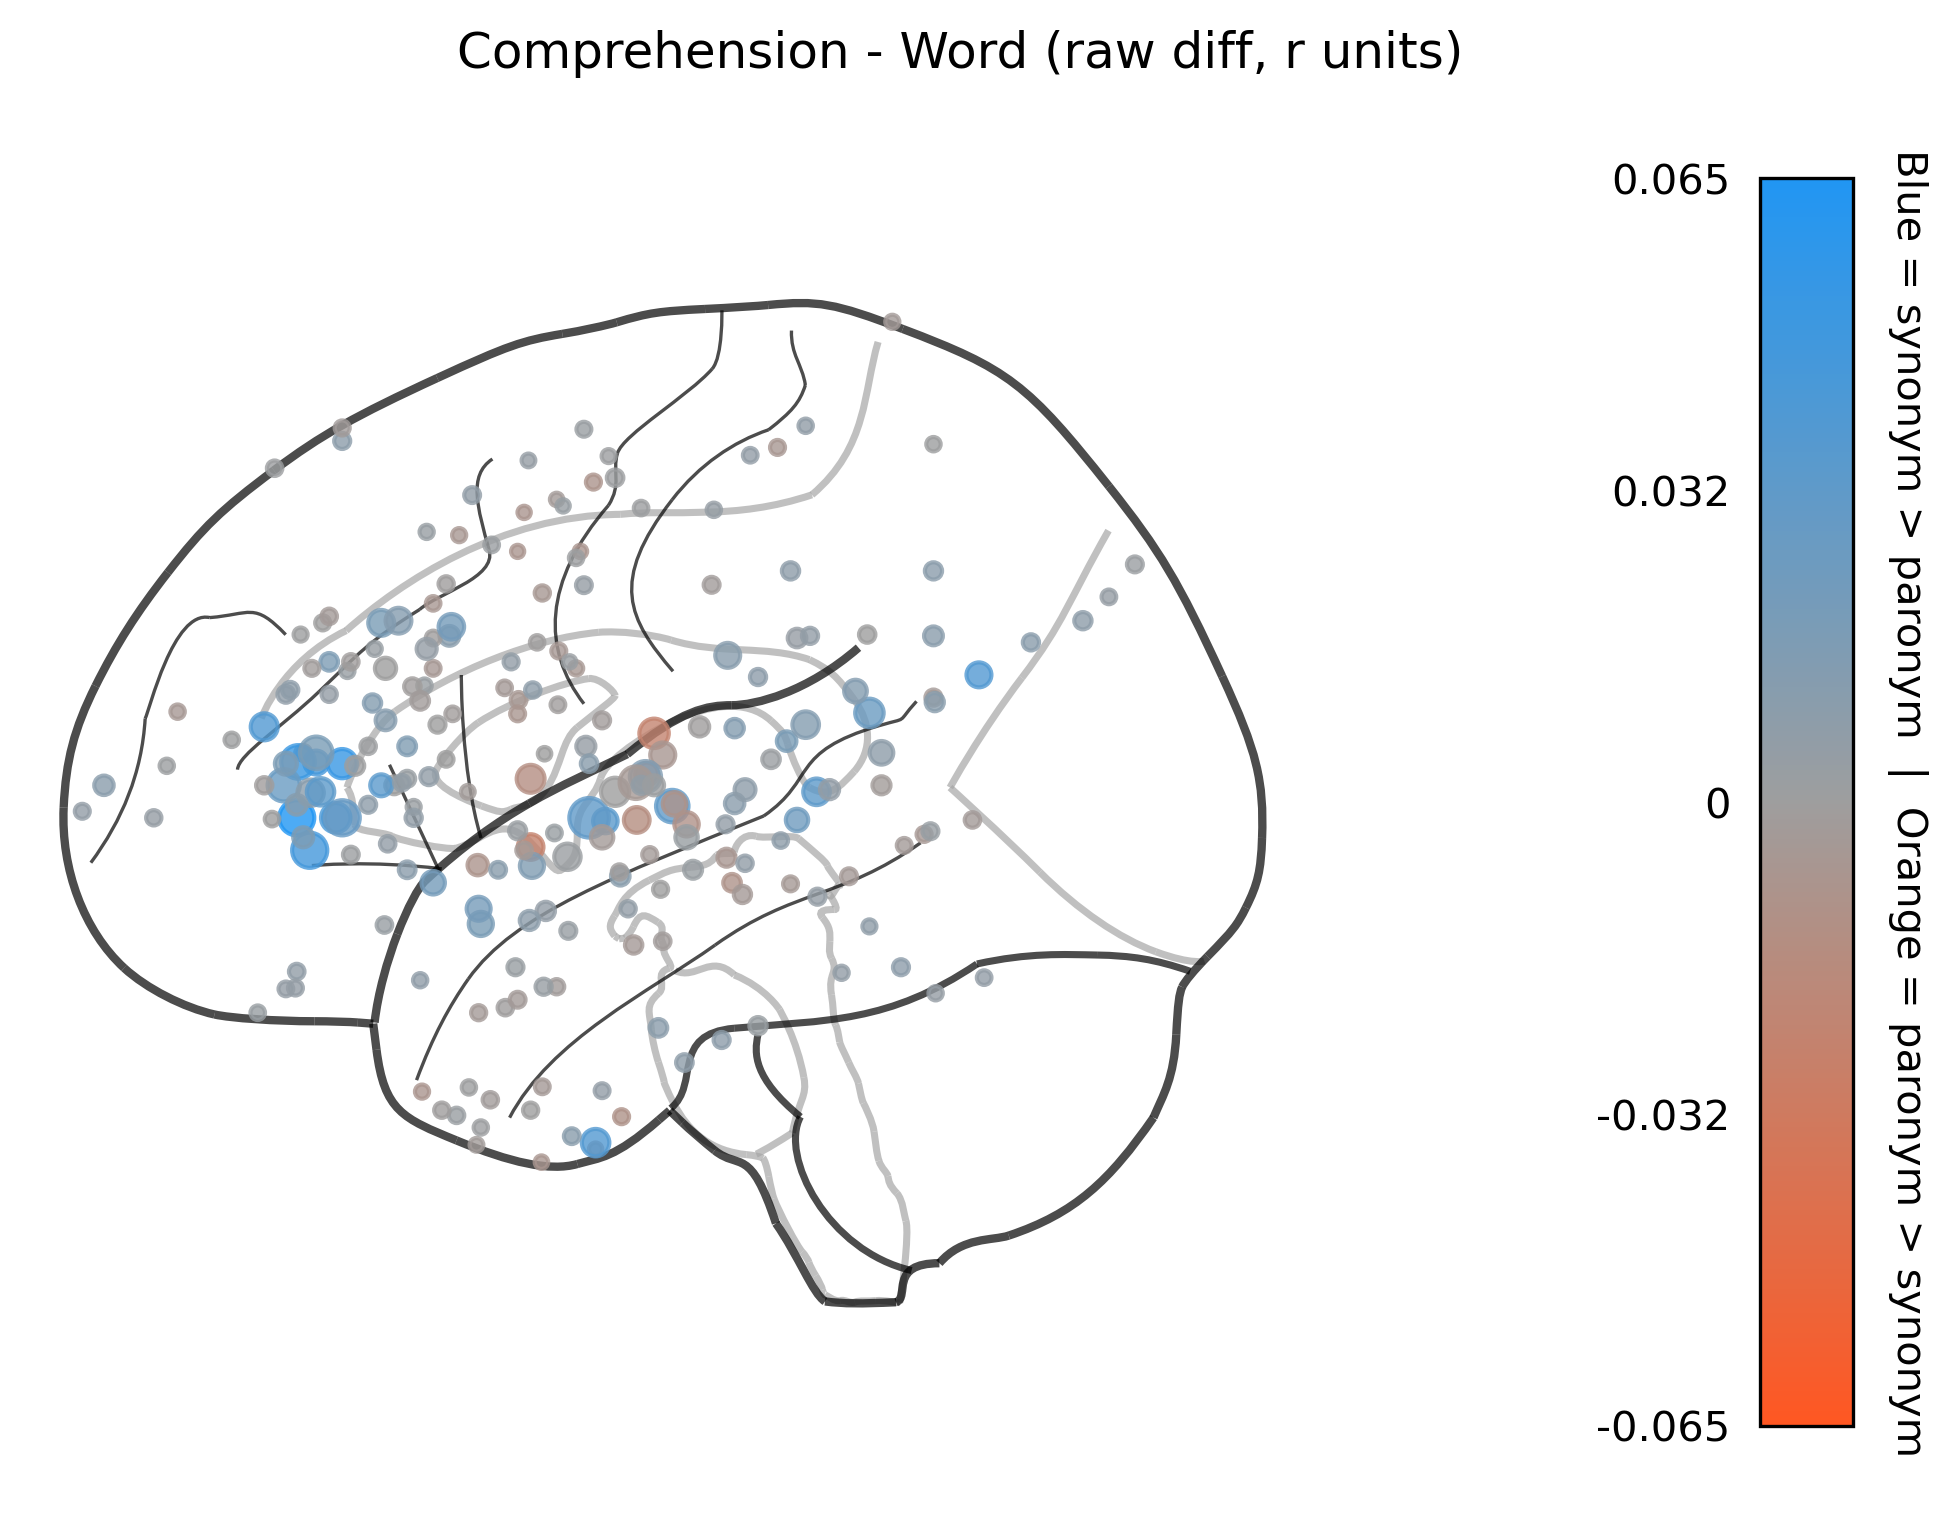

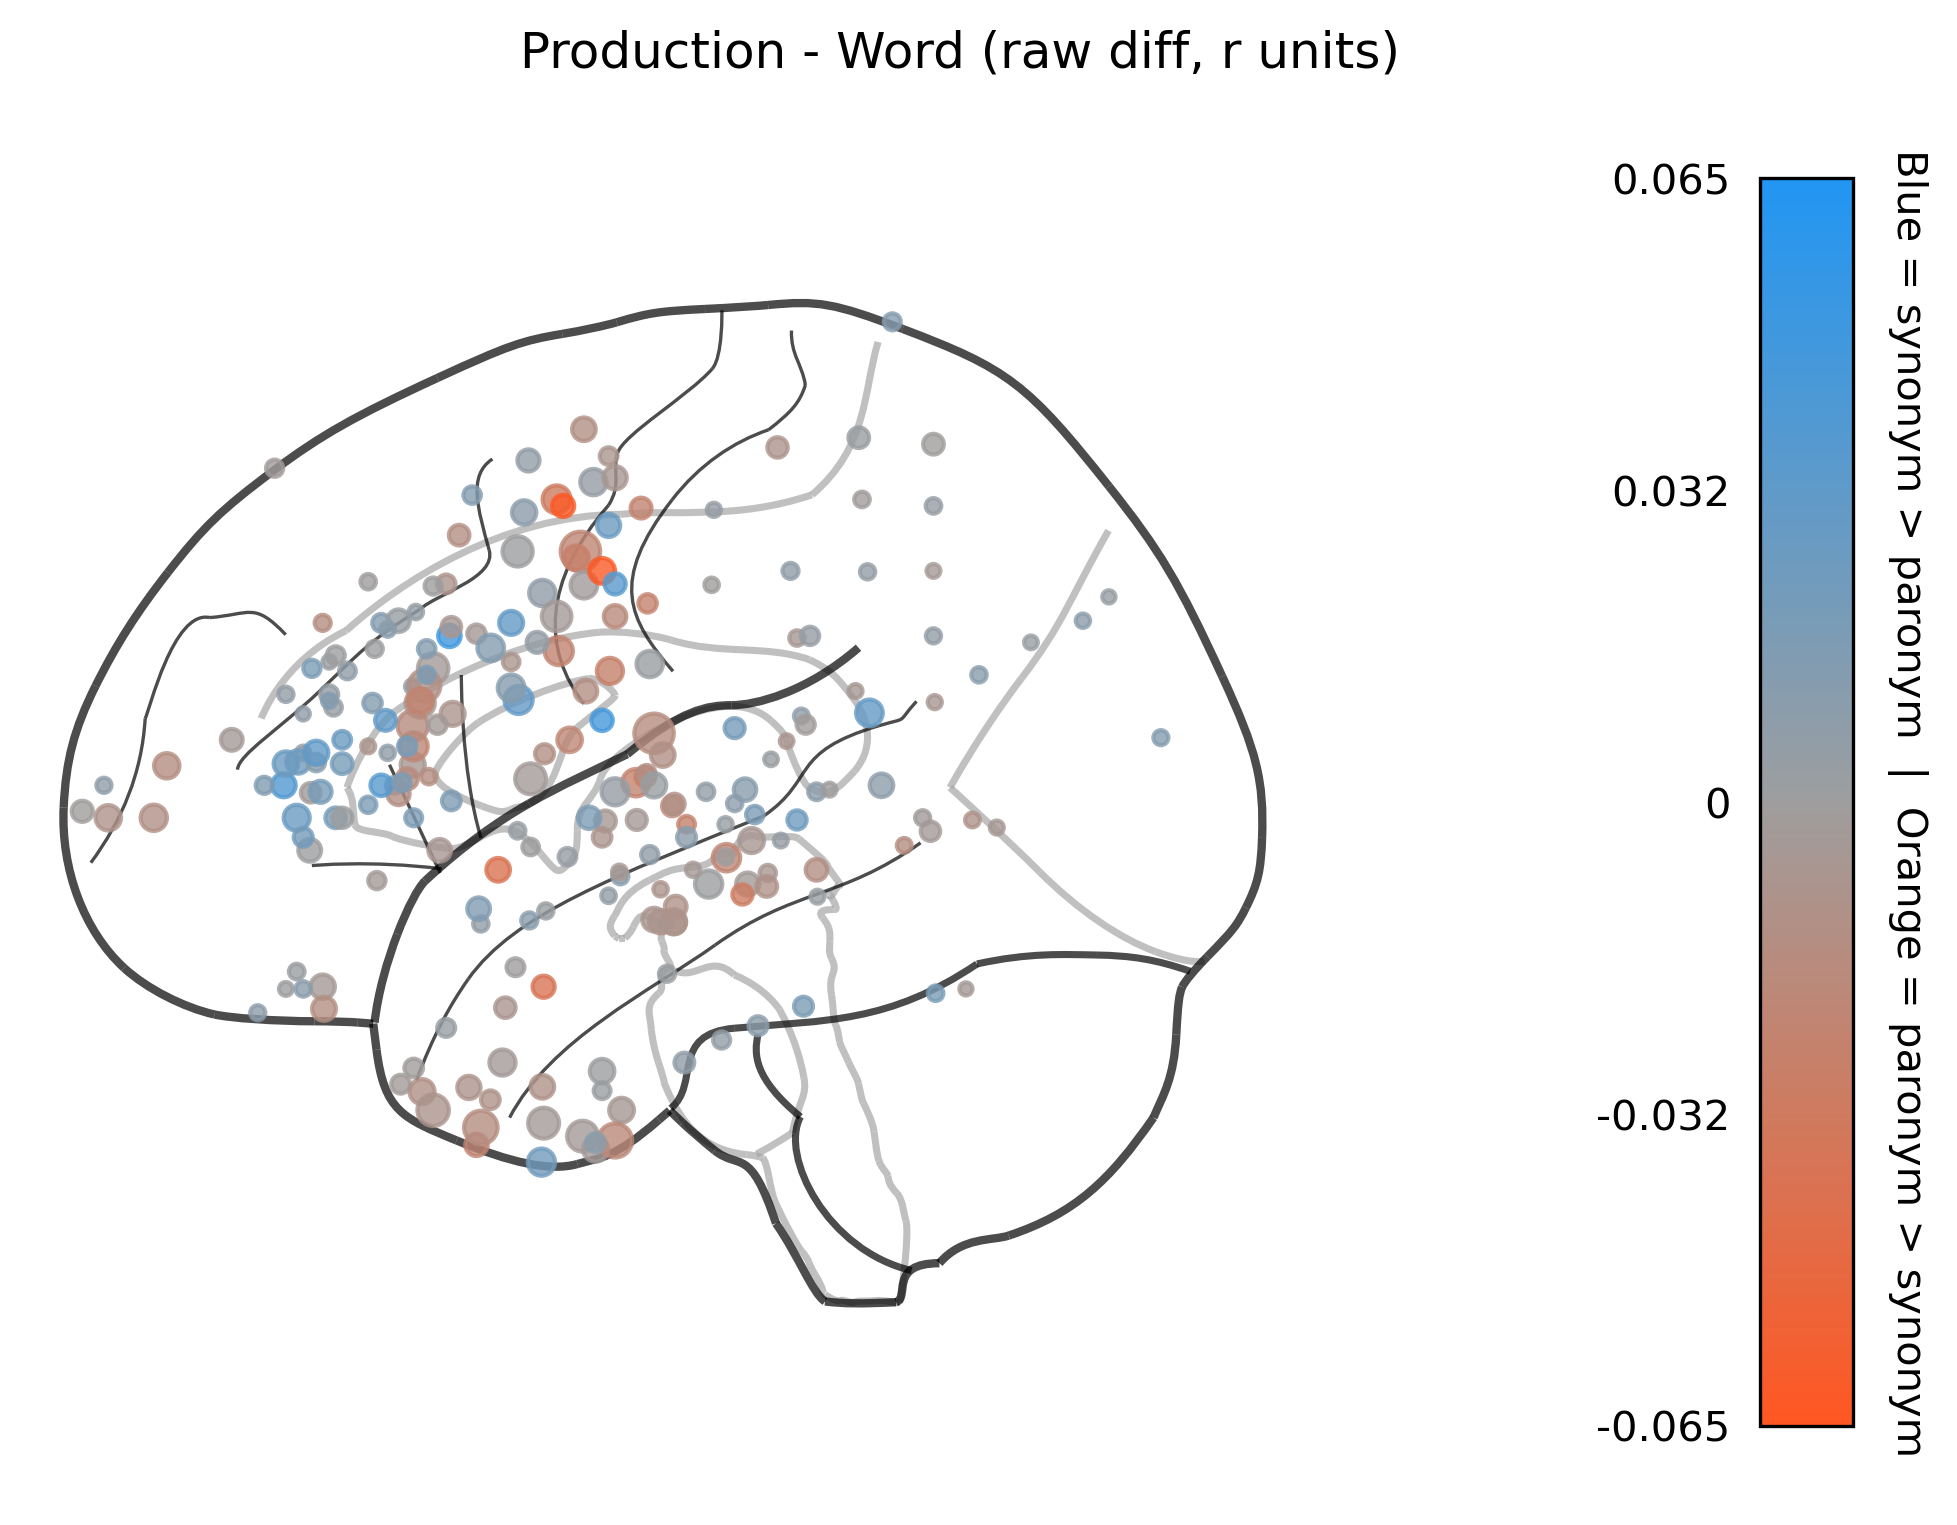

In [10]:
importlib.reload(ru)

ru.render_raw_diff_brainplots(
    electrode_scores=electrode_scores,
    plot_order=plot_order,
    cmaps=cmaps,
    colorbar_labels=colorbar_labels,
    use_size_encoding=True,
)